# Origin Of PDEs

## Definition Of PDE


:::{prf:definition} Partial Differential Equaiton
Let $u\in C^{\infty}(\mathbb{R}^n,\mathbb{R}^m)$, let $F$ be an operator between $C^{\infty}(\mathbb{R}^n,\mathbb{R}^m)$. Let $g$ be another function in $ C^{\infty}(\mathbb{R}^n,\mathbb{R}^m)$. PDEs have the general form 
\begin{equation}
F(u)=g
\end{equation}
The order of the PDE is given by the highest order derivative operator appeared in $F$. If $F$ is a linear operator, we call the PDE **linear**. If $g=0$, we call the PDE **homogenous**. 
:::


Recall linearity means $F(u+av)=F(u)+aF(v)$. To see if an opeartor is linear or not we can just plug into $F$ on both side and check the equivalence. For instance, suppose we work on $C^{\infty}(\mathbb{R}^2, \mathbb{R})$. Let $F=\partial_x + y\partial_y$. The LHS would be:
\begin{align*}
F(u+av) &= \partial_x(u+av) + y\partial_y(u+av) \\
&= u_x + av_x + y(u_y+av_y) \\
\end{align*}
The RHS is:
\begin{align*}
F(u) + aF(v) &= u_x + yu_y + a(v_x + yv_y)\\
&= u_x +av_x + y(u_y + av_y)
\end{align*}

Which is equal hence $F=\partial_x + y\partial_y$ is indeed linear. In general linearity is guaranteed as long as we don't multiply any of $u, u_x, u_y, u_{xx}, u_{yy}, u_{xy}....$ together in $F$. 



## Diffusion/Heat Equation


Both diffusion and heat transport follows a single, simple rule:
:::{tip} Fick's Law
The rate of concentration/temperature change is proportioanl to the concentration/temperature gradient. 
:::

This turns out to be all we need to know to compute the exact of a system given some inital state. 

Let $u$ be temeprature/concentration, then 
$$
\int_{D} u_t dV = \int_{\partial D} k (\nabla u \cdot \vec n) dS
$$
In 3 dimension, we have 

$$
\iiint_D  u_t dx dy dz= \iint_{\partial D} k (\nabla u \cdot \vec n) dS
$$
By divergence theorem, the RHS becomes 

$$
\iiint_{D} k \nabla \cdot (\nabla u) dxdydz  
$$

Since $D$ is arbitrary we have:

$$u_t = k\Delta u$$

where $\Delta = \nabla \cdot \nabla $ is the laplacian. 

:::{prf:definition}
The diffusion/heat equation is defined as:

\begin{equation}
u_t = k\Delta u
\end{equation}
:::

Before we do any analytical solve, we first introduce the central idea behind numercial methods. 

Let's consider a 1D toy heat equation 
:::{attention} Problem Statement 
\begin{equation}
u_t = \alpha u_{xx}
\end{equation}
We use $\Omega=[0,1] \mathrm{(cm)}$ to depict the spatial domaion. Let $J=[0,\infty) \mathrm{(s)}$ be the temporal domain. 

$\alpha$ here is the thermal diffusivity. Let's consider a thin, iron rod. The thermal diffusivity would be approximately $6 \cdot 10^{-2} \mathrm{\frac{cm^2}{s}}$

The boundary conditions are $u(t,0)=0$, $u(t,1)=0$ and initial conditions $u(0,x)=u_0$ where 
$$
u_0 = 273.15 + 27 \cdot \exp(-((x-0.5)/0.01)^2)
$$
which is a sharp bell curve centered at the center of our iron rod. 
:::

Note this is just depicting an iron rod of lenght 1cm with the center heated up to approximately 27C and the rest at 0C.




### Explicit Fully-Discrete Method
:::{tip}
Fully-discrete means to discretize both $\Omega$ and $J$, i.e.,
$\Omega = [x_0, x_1,...,x_N], J = [t_0,t_1,...,t_m]$. Fully-discrete method reduces a continuous problem to an algebraic system. An alternative is semi-discrete method, which reduces a continuos problem to an ODE which can be further reduced to algebraic system mentioned in the last chapter. 
:::

As CS student this algorithm can't feel more familiar. Stencil algorithms resembles DP(*Dynamic Programming*) significantly. The base case is the initial condition and we iterate up in time to resolve the dependency. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm

First let's write a small helper function to complete the key step:

$$
    u(t+1,i)=u(t, i) + c\frac{\Delta t}{(\Delta x^2)}(u(t, i+1)-2u(t, i)+u(t, i-1))
$$

In [3]:
def shift_numpy_array(array : np.ndarray, step : int):
    if(step > 0): #shift right
        array = np.pad(array[0 : len(array)-step], pad_width=(step, 0), constant_values=0)
    elif(step < 0): #shift left
        step = -step
        array = np.pad(array[step : len(array)], pad_width=(0, step), constant_values=0)
    return array 

We implement the forward method as a single loop:

In [4]:
def solve_1Dheat_equation(Omega, 
                          time_steps, 
                          alpha, 
                          u0, 
                          boundary, 
                          temporal_resol, 
                          spatial_resol):
    total_space_voxels = int((Omega[1]-Omega[0])/spatial_resol)
    time_series = np.empty(shape=(time_steps, total_space_voxels))
    time_series[0] = u0
    for t in tqdm(range(1, time_steps)):
        u = time_series[t-1]
        u_xx = shift_numpy_array(u, -1) - 2 * u + shift_numpy_array(u, 1)
        time_series[t] = u + alpha * (temporal_resol / (spatial_resol ** 2)) * u_xx 
        time_series[t, 0] = boundary[0]
        time_series[t, -1] = boundary[-1]
    return time_series

Note this line encodes the temporal update from $t-1$ to $t$:

```python
 u_xx = shift_numpy_array(u, -1) - 2 * u + shift_numpy_array(u, 1)
```

Let's define the initial condition as a sharp bell curve

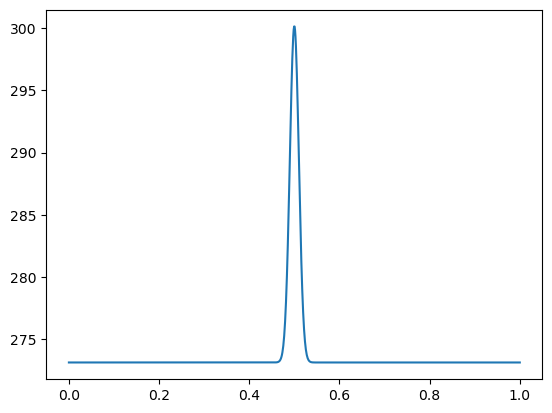

In [12]:
x = np.linspace(0, 1, 1000)
#inital condition
u0 = np.exp(-0.5 * ((x-0.5)/0.01)**2)  * 27 + 273.15
fig, ax = plt.subplots()
ax.plot(x, u0)


First let's set the paramters of the equation and simulation:
1. Temporal resolution is exactly $\Delta t$($s$), similarily, spatial resolution is $\Delta x$($cm$)
2. $\Omega$ is a tuple representing the 1D interval of the space domain 
3. `boundary` is a tuple representing the boundary condition, i.e., what's the temperature at the ends of the iron rod 
4. $\alpha$ is again, the thermal diffusivity 

In [18]:
temporal_resol = 1e-6 
spatial_resol = 1e-3 
time_steps = int(1e6) 
Omega=(0,1) #space domain
boundary=(273.15,273.15)
alpha=1e-2*6 #unit in cm^2/s

In [19]:

eq_params = {    
    "Omega" : Omega, #space domain
    "alpha" : alpha, #thermal diffusivity
    "u0" : u0, #inital condition
    "boundary" : boundary
}

sim_param = {
    "temporal_resol" : temporal_resol, 
    "spatial_resol" : spatial_resol,
    "time_steps" : time_steps
}

U = solve_1Dheat_equation(**eq_params, **sim_param)


100%|██████████| 999999/999999 [00:22<00:00, 44154.15it/s]


We visualize by animating over time

In [10]:
def animate1dPDEsolution(solution : np.ndarray, 
                         title : str, 
                         output_path : str, 
                         x_unit : str, 
                         y_unit : str, 
                         t_unit : str, 
                         time_factor : int, 
                         fps : int, 
                         coarsen_factor : int =10):
    """plot 1d pde solution

    Args:
        solution : 2D np array, the 0th axis being time, 1th axis being space
        title : the porition of title of the plot that's invariant between frames 
        output_path : where to save the output mp4 to
        time_factor : the ratio between real time and simulation time
        coarsen_factor (int, optional): for speed up, plot once per coarsen_factor

    Returns:
        _type_: _description_
    """
    fig, ax = plt.subplots()
    u = solution[0]
    sol_curr = ax.plot(x, u)[0]
    ax.set(xlabel=f"x {x_unit}", ylabel=f"T {y_unit}", title=f"f1D {title} at Time 0 {t_unit}")
        
    def update(t):
         # sparse plot to speed up
        sol_curr.set_ydata(solution[t * coarsen_factor])
        time = (int)(t * coarsen_factor * time_factor)
        ax.set_title(f"1D {title} at Time {time} {t_unit}")
        return (sol_curr, )

    anim = animation.FuncAnimation(fig = fig, func=update, frames=int(len(solution) / coarsen_factor), interval=30)
    anim.save(filename=output_path, fps=fps)

Set some animation parameters: 

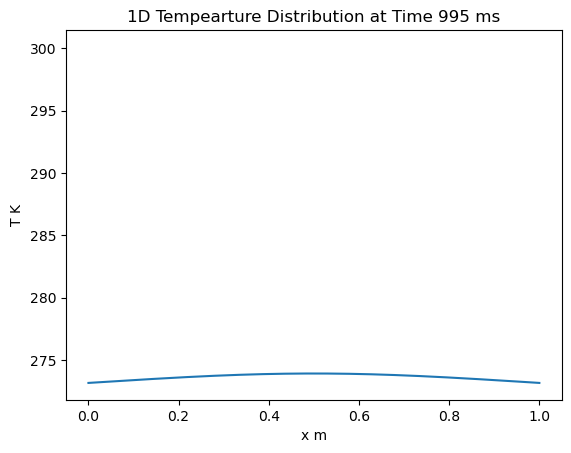

In [20]:

animate_arg = {
    "solution" : U,
    "output_path" : "output/1dheat.mp4", 
    "fps" : 40,
    "x_unit" : "m", 
    "y_unit" : "K",
    "time_factor" : temporal_resol * 1e3,
    "coarsen_factor" : 5000, # for speed up, plot once per 5000 step
    "title" : "Tempearture Distribution", 
    "t_unit" : "ms"
}

animate1dPDEsolution(**animate_arg)

We can view the full solution(a "video") by opening the saved mp4 file:

In [21]:
from IPython.display import Video
Video("output/1dheat.mp4", width=400)